# Segmentation for Water Detection

This notebook demonstrates a semantic segmentation pipeline using a SegFormer model to detect water in images. It covers data loading, preprocessing, model training, and evaluation.

In [1]:
!pip install torch torchvision transformers albumentations \
             opencv-python matplotlib scikit-learn tqdm Pillow scipy -q

## Initialization and Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import torch

# Paths
DATASET_ROOT = "/content/drive/MyDrive/dataset"
IMAGE_DIR    = f"{DATASET_ROOT}/images"
MASK_DIR     = f"{DATASET_ROOT}/masks"
DAY_DIR      = f"{IMAGE_DIR}/day"
NIGHT_DIR    = f"{IMAGE_DIR}/night"
SAVE_PATH    = "/content/drive/MyDrive/water_best_v3.pth"

# ROI
ROI          = (342, 462, 1062, 1182)   # 720×720
ORIG_H       = 1080                     # ← Adjust according to actual image
ORIG_W       = 1920                     # ← Adjust according to actual image

# Training
IMG_SIZE     = 512
BATCH_SIZE   = 2
EPOCHS       = 30
LR           = 6e-5
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device     : {DEVICE}")
print(f"ROI        : {ROI}")
print(f"Orig size  : {ORIG_W}×{ORIG_H}")
print(f"IMG_SIZE   : {IMG_SIZE}")

Mounted at /content/drive
Device     : cuda
ROI        : (342, 462, 1062, 1182)
Orig size  : 1920×1080
IMG_SIZE   : 512


## Data Loading and Splitting

In [3]:
import os, cv2
import numpy as np
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split

def load_dataset(day_dir, night_dir, mask_dir):
    data = []
    for label, folder in [("day", day_dir), ("night", night_dir)]:
        if not os.path.exists(folder):
            print(f"Not found: {folder}")
            continue
        for fname in sorted(os.listdir(folder)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            stem       = Path(fname).stem
            mask_fname = next(
                (m for m in os.listdir(mask_dir) if Path(m).stem == stem),
                None
            )
            if mask_fname is None:
                print(f"No mask for {fname}")
                continue
            data.append((
                os.path.join(folder, fname),
                os.path.join(mask_dir, mask_fname),
                label
            ))
    return data

data   = load_dataset(DAY_DIR, NIGHT_DIR, MASK_DIR)
imgs   = [d[0] for d in data]
masks  = [d[1] for d in data]
labels = [d[2] for d in data]

# Step 1: Test 10%
train_val_imgs,  test_imgs,  \
train_val_masks, test_masks, \
train_val_labels, test_labels = train_test_split(
    imgs, masks, labels,
    test_size=0.10, stratify=labels, random_state=42
)

# Step 2: Val 10%
train_imgs,  val_imgs,  \
train_masks, val_masks, \
train_labels, val_labels = train_test_split(
    train_val_imgs, train_val_masks, train_val_labels,
    test_size=0.1111, stratify=train_val_labels, random_state=42
)

print(f"Total : {len(data)} images")
print(f"{'Split':<12} {'Total':>6} {'Day':>6} {'Night':>6}")
print("-" * 32)
for name, lbl in [("Train",      train_labels),
                  ("Validation", val_labels),
                  ("Test",       test_labels)]:
    d = lbl.count("day")
    n = lbl.count("night")
    print(f"{name:<12} {len(lbl):>6} {d:>6} {n:>6}")

Total : 1204 images
Split         Total    Day  Night
--------------------------------
Train           962    473    489
Validation      121     60     61
Test            121     60     61


## Data Augmentation and DataLoaders

In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05,
                       rotate_limit=3, p=0.5),
    # Color before ToGray
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=40,
                         val_shift_limit=40, p=0.5),
    # Lighting
    A.RandomBrightnessContrast(brightness_limit=0.4,
                               contrast_limit=0.4, p=0.9),
    A.RandomGamma(gamma_limit=(60, 140), p=0.5),
    # Simulate night IR
    A.ToGray(p=0.5),
    # Noise
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.GaussNoise(p=0.5),
    A.ImageCompression(quality_lower=60, quality_upper=95, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class WaterDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.transform  = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        image = cv2.cvtColor(
            cv2.imread(self.img_paths[idx]), cv2.COLOR_BGR2RGB
        )
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.uint8)
        aug  = self.transform(image=image, mask=mask)
        return aug["image"], aug["mask"].long()

train_loader = DataLoader(
    WaterDataset(train_imgs, train_masks, train_transform),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    WaterDataset(val_imgs, val_masks, val_transform),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    WaterDataset(test_imgs, test_masks, val_transform),
    batch_size=1, shuffle=False, num_workers=2
)

print(f"   Train  : {len(train_loader)} batches")
print(f"   Val    : {len(val_loader)} batches")
print(f"   Test   : {len(test_loader)} batches")

   Train  : 481 batches
   Val    : 61 batches
   Test   : 121 batches


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_2331/3827808165.py:22: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=60, quality_upper=95, p=0.3),


## Model Definition

In [5]:
import gc
from transformers import SegformerForSemanticSegmentation

torch.cuda.empty_cache()
gc.collect()

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512",
    num_labels=2,
    id2label={0: "background", 1: "water"},
    label2id={"background": 0, "water": 1},
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

print(f"Model loaded on {DEVICE}")
print(f"   VRAM free : {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded on cuda
   VRAM free : 14.35 GB


## Loss Functions, Optimizer, and Metrics

In [6]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.ndimage import binary_erosion

# Loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)[:, 1]
        tgt   = targets.float()
        inter = (probs * tgt).sum(dim=(1, 2))
        dice  = 1 - (2 * inter + self.smooth) / \
                (probs.sum(dim=(1,2)) + tgt.sum(dim=(1,2)) + self.smooth)
        return dice.mean()

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
    def forward(self, logits, targets):
        return self.ce(logits, targets) + self.dice(logits, targets)

criterion = CombinedLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ROI Scaling
def get_roi_scaled(H, W):
    """Scale ROI from original image size → prediction size (512×512)"""
    x1, y1, x2, y2 = ROI
    sx = W / ORIG_W
    sy = H / ORIG_H
    return (
        max(0, min(int(x1 * sx), W)),
        max(0, min(int(y1 * sy), H)),
        max(0, min(int(x2 * sx), W)),
        max(0, min(int(y2 * sy), H)),
    )

# Metrics
def compute_iou_roi(preds, targets):
    H, W = preds.shape[-2], preds.shape[-1]
    x1, y1, x2, y2 = get_roi_scaled(H, W)
    p = preds[...,   y1:y2, x1:x2].bool()
    t = targets[..., y1:y2, x1:x2].bool()
    inter = (p & t).float().sum((1, 2))
    union = (p | t).float().sum((1, 2))
    return ((inter + 1e-6) / (union + 1e-6)).mean().item()

def get_boundary(mask_np, dilation=2):
    eroded = binary_erosion(mask_np, iterations=dilation)
    return mask_np.astype(bool) & ~eroded

def compute_biou_roi(preds, targets, dilation=2):
    H, W = preds.shape[-2], preds.shape[-1]
    x1, y1, x2, y2 = get_roi_scaled(H, W)
    scores = []
    for p, t in zip(preds.cpu().numpy(), targets.cpu().numpy()):
        bp = get_boundary(p[y1:y2, x1:x2], dilation)
        bt = get_boundary(t[y1:y2, x1:x2], dilation)
        scores.append((bp & bt).sum() / ((bp | bt).sum() + 1e-6))
    return float(np.mean(scores))

# Verify scaled ROI
print(f"   ROI original : {ROI}")
print(f"   ROI scaled   : {get_roi_scaled(IMG_SIZE, IMG_SIZE)}")
print(f"   (บน {IMG_SIZE}×{IMG_SIZE})")

   ROI original : (342, 462, 1062, 1182)
   ROI scaled   : (91, 219, 283, 512)
   (บน 512×512)


## Training Loop

In [ ]:
from tqdm import tqdm

best_biou = 0.0
history   = {
    "train_loss": [], "val_loss": [],
    "val_iou":    [], "val_biou": []
}

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()
    train_loss = 0.0

    for images, masks in tqdm(train_loader,
                              desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]",
                              leave=False):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        logits = model(pixel_values=images).logits
        logits = F.interpolate(logits, size=masks.shape[-2:],
                               mode="bilinear", align_corners=False)
        loss   = criterion(logits, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss = val_iou = val_biou = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader,
                                  desc=f"Epoch {epoch:02d}/{EPOCHS} [Val]  ",
                                  leave=False):
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(pixel_values=images).logits
            logits = F.interpolate(logits, size=masks.shape[-2:],
                                   mode="bilinear", align_corners=False)
            preds  = logits.argmax(dim=1)
            val_loss += criterion(logits, masks).item()
            val_iou  += compute_iou_roi(preds, masks)
            val_biou += compute_biou_roi(preds, masks)

    avg_train = train_loss / len(train_loader)
    avg_vloss = val_loss   / len(val_loader)
    avg_iou   = val_iou    / len(val_loader)
    avg_biou  = val_biou   / len(val_loader)
    scheduler.step()

    for k, v in zip(
        ["train_loss", "val_loss", "val_iou", "val_biou"],
        [avg_train, avg_vloss, avg_iou, avg_biou]
    ):
        history[k].append(v)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {avg_train:.4f} | "
          f"Val Loss: {avg_vloss:.4f} | "
          f"IoU: {avg_iou:.4f} | "
          f"BIoU: {avg_biou:.4f}")

    if avg_biou > best_biou:
        best_biou = avg_biou
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  ✅ Best saved — BIoU: {best_biou:.4f}")

print(f"\n🏆 Training complete — Best BIoU(ROI): {best_biou:.4f}")

Epoch 01/30 | Train Loss: 0.2223 | Val Loss: 0.0421 | IoU: 0.9812 | BIoU: 0.5931
  ✅ Best saved — BIoU: 0.5931


Epoch 02/30 | Train Loss: 0.0806 | Val Loss: 0.0294 | IoU: 0.9843 | BIoU: 0.6128
  ✅ Best saved — BIoU: 0.6128


Epoch 03/30 | Train Loss: 0.0674 | Val Loss: 0.0259 | IoU: 0.9860 | BIoU: 0.6483
  ✅ Best saved — BIoU: 0.6483


Epoch 04/30 | Train Loss: 0.0627 | Val Loss: 0.0244 | IoU: 0.9865 | BIoU: 0.6622
  ✅ Best saved — BIoU: 0.6622


Epoch 05/30 | Train Loss: 0.0529 | Val Loss: 0.0231 | IoU: 0.9868 | BIoU: 0.6628
  ✅ Best saved — BIoU: 0.6628


...

Epoch 26/30 | Train Loss: 0.0290 | Val Loss: 0.0190 | IoU: 0.9904 | BIoU: 0.7302


Epoch 27/30 | Train Loss: 0.0286 | Val Loss: 0.0189 | IoU: 0.9905 | BIoU: 0.7318
  ✅ Best saved — BIoU: 0.7318


Epoch 28/30 | Train Loss: 0.0280 | Val Loss: 0.0190 | IoU: 0.9905 | BIoU: 0.7311


Epoch 29/30 | Train Loss: 0.0276 | Val Loss: 0.0190 | IoU: 0.9905 | BIoU: 0.7313


Epoch 30/30 | Train Loss: 0.0273 | Val Loss: 0.0189 | IoU: 0.9905 | BIoU: 0.7307

🏆 Training complete — Best BIoU(ROI): 0.7318


## Training History Visualization

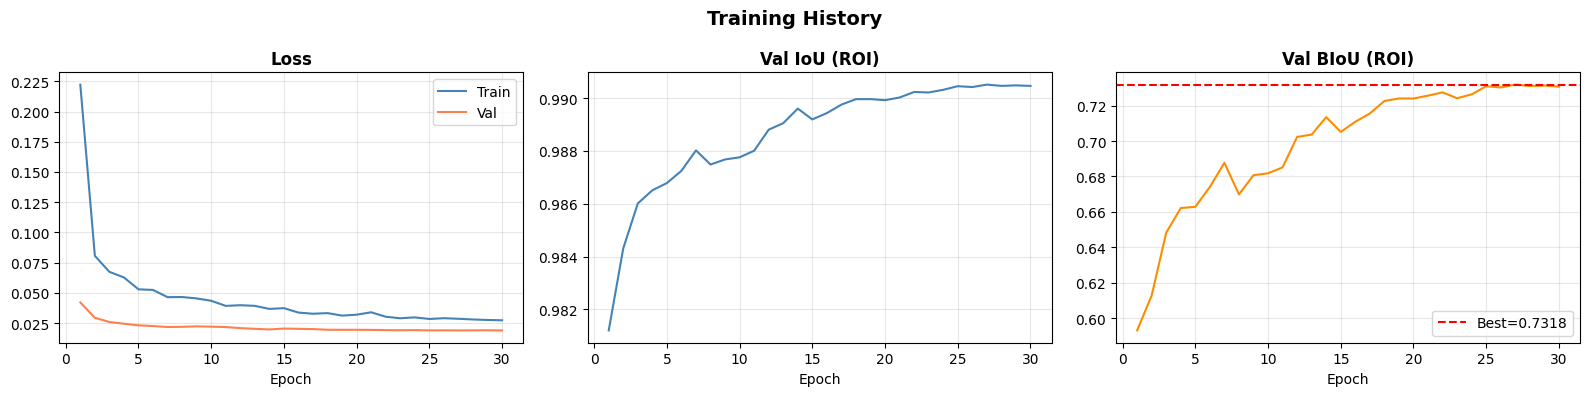

In [ ]:
import matplotlib.pyplot as plt

x = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(x, history["train_loss"], label="Train", color="steelblue")
axes[0].plot(x, history["val_loss"],   label="Val",   color="coral")
axes[0].set_title("Loss", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xlabel("Epoch")

axes[1].plot(x, history["val_iou"], color="steelblue")
axes[1].set_title("Val IoU (ROI)", fontweight="bold")
axes[1].grid(alpha=0.3); axes[1].set_xlabel("Epoch")

axes[2].plot(x, history["val_biou"], color="darkorange")
axes[2].axhline(best_biou, color="red", linestyle="--",
                label=f"Best={best_biou:.4f}")
axes[2].set_title("Val BIoU (ROI)", fontweight="bold")
axes[2].legend(); axes[2].grid(alpha=0.3); axes[2].set_xlabel("Epoch")

plt.suptitle("Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/curves_v3.png", dpi=150)
plt.show()

## Test Set Evaluation

In [ ]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

test_iou = test_biou = 0.0
all_preds      = []
all_masks_list = []

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing"):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        logits = model(pixel_values=images).logits
        logits = F.interpolate(logits, size=masks.shape[-2:],
                               mode="bilinear", align_corners=False)
        preds  = logits.argmax(dim=1)
        test_iou  += compute_iou_roi(preds, masks)
        test_biou += compute_biou_roi(preds, masks)
        all_preds.append(preds.cpu())
        all_masks_list.append(masks.cpu())

n = len(test_loader)
print(f"\n{'='*45}")
print(f"{'TEST RESULTS':^45}")
print(f"{'='*45}")
print(f"  IoU  (ROI) : {test_iou/n:.4f}")
print(f"  BIoU (ROI) : {test_biou/n:.4f}")
print(f"{'='*45}")

Testing: 100%|██████████| 121/121 [00:32<00:00,  3.76it/s]


                TEST RESULTS                 
  IoU  (ROI) : 0.9863
  BIoU (ROI) : 0.7328


## Test Set Prediction Visualization

In [ ]:
import random, matplotlib.pyplot as plt

x1, y1, x2, y2 = ROI
sample_idx = random.sample(range(len(test_imgs)), min(6, len(test_imgs)))

fig, axes = plt.subplots(len(sample_idx), 4,
                         figsize=(20, 5 * len(sample_idx)))

for row, idx in enumerate(sample_idx):
    orig     = np.array(Image.open(test_imgs[idx]).convert("RGB"))
    pred_np  = all_preds[idx][0].numpy()
    mask_np  = all_masks_list[idx][0].numpy()

    pred_disp = cv2.resize(pred_np.astype(np.uint8),
                           (orig.shape[1], orig.shape[0]),
                           interpolation=cv2.INTER_NEAREST)
    mask_disp = cv2.resize(mask_np.astype(np.uint8),
                           (orig.shape[1], orig.shape[0]),
                           interpolation=cv2.INTER_NEAREST)

    overlay = orig.copy()
    overlay[pred_disp == 1] = (
        overlay[pred_disp == 1] * 0.5 + np.array([0, 100, 255]) * 0.5
    ).astype(np.uint8)
    cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Boundary visualization on the ROI of the original image
    bp   = get_boundary(pred_disp[y1:y2, x1:x2])
    bt   = get_boundary(mask_disp[y1:y2, x1:x2])
    bvis = np.zeros((*bp.shape, 3), dtype=np.uint8)
    bvis[bt]       = [0,   255,   0]
    bvis[bp]       = [255, 100,   0]
    bvis[bt & bp]  = [255, 255, 255]

    iou  = compute_iou_roi(all_preds[idx],  all_masks_list[idx])
    biou = compute_biou_roi(all_preds[idx], all_masks_list[idx])

    axes[row][0].imshow(orig)
    axes[row][0].set_title("Original"); axes[row][0].axis("off")

    axes[row][1].imshow(mask_disp, cmap="gray")
    axes[row][1].set_title("Ground Truth"); axes[row][1].axis("off")

    axes[row][2].imshow(overlay)
    axes[row][2].set_title(f"Prediction\nIoU={iou:.3f}"); axes[row][2].axis("off")

    axes[row][3].imshow(bvis)
    axes[row][3].set_title(
        f"Boundary (ROI)\nGT  Pred  Match\nBIoU={biou:.3f}"
    )
    axes[row][3].axis("off")

plt.suptitle("Test Set Predictions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/predictions_v3.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Score Distribution Analysis

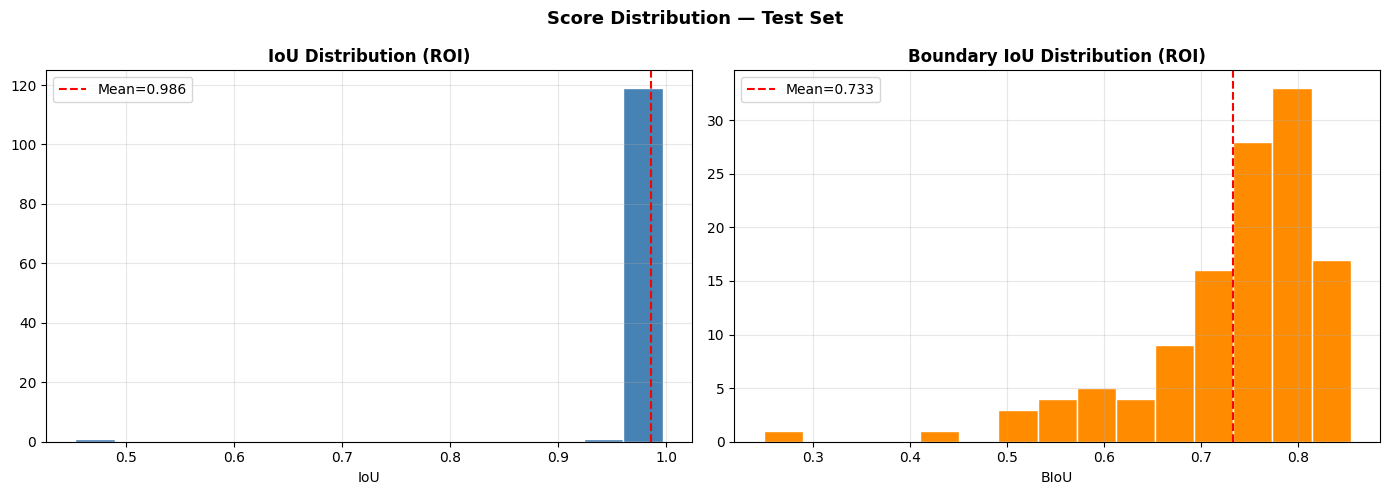

In [ ]:
per_iou  = [compute_iou_roi(all_preds[i],  all_masks_list[i])
            for i in range(len(all_preds))]
per_biou = [compute_biou_roi(all_preds[i], all_masks_list[i])
            for i in range(len(all_preds))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(per_iou,  bins=15, color="steelblue", edgecolor="white")
axes[0].axvline(np.mean(per_iou), color="red", linestyle="--",
                label=f"Mean={np.mean(per_iou):.3f}")
axes[0].set_title("IoU Distribution (ROI)", fontweight="bold")
axes[0].set_xlabel("IoU"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(per_biou, bins=15, color="darkorange", edgecolor="white")
axes[1].axvline(np.mean(per_biou), color="red", linestyle="--",
                label=f"Mean={np.mean(per_biou):.3f}")
axes[1].set_title("Boundary IoU Distribution (ROI)", fontweight="bold")
axes[1].set_xlabel("BIoU"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Score Distribution — Test Set", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/distribution_v3.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Inference Setup and Saving Predictions

In [7]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from scipy.ndimage import binary_erosion
from transformers import SegformerForSemanticSegmentation
import gc

# Model
torch.cuda.empty_cache()
gc.collect()

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512",
    num_labels=2,
    id2label={0: "background", 1: "water"},
    label2id={"background": 0, "water": 1},
    ignore_mismatched_sizes=True,
)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print(f" Model loaded from {SAVE_PATH}")

# Transform
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Dataset
class WaterDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.transform  = transform
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        image = cv2.cvtColor(cv2.imread(self.img_paths[idx]), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask  = (mask > 127).astype(np.uint8)
        aug   = self.transform(image=image, mask=mask)
        return aug["image"], aug["mask"].long()

test_loader = DataLoader(
    WaterDataset(test_imgs, test_masks, val_transform),
    batch_size=1, shuffle=False, num_workers=2
)

# Metrics
def get_roi_scaled(H, W):
    x1, y1, x2, y2 = ROI
    sx = W / ORIG_W; sy = H / ORIG_H
    return (max(0,min(int(x1*sx),W)), max(0,min(int(y1*sy),H)),
            max(0,min(int(x2*sx),W)), max(0,min(int(y2*sy),H)))

def compute_iou_roi(preds, targets):
    H, W = preds.shape[-2], preds.shape[-1]
    x1,y1,x2,y2 = get_roi_scaled(H, W)
    p = preds[..., y1:y2, x1:x2].bool()
    t = targets[..., y1:y2, x1:x2].bool()
    inter = (p & t).float().sum((1,2))
    union = (p | t).float().sum((1,2))
    return ((inter+1e-6)/(union+1e-6)).mean().item()

def get_boundary(mask_np, dilation=2):
    return mask_np.astype(bool) & ~binary_erosion(mask_np, iterations=dilation)

def compute_biou_roi(preds, targets, dilation=2):
    H, W = preds.shape[-2], preds.shape[-1]
    x1,y1,x2,y2 = get_roi_scaled(H, W)
    scores = []
    for p, t in zip(preds.cpu().numpy(), targets.cpu().numpy()):
        bp = get_boundary(p[y1:y2,x1:x2], dilation)
        bt = get_boundary(t[y1:y2,x1:x2], dilation)
        scores.append((bp&bt).sum()/((bp|bt).sum()+1e-6))
    return float(np.mean(scores))

print("Metrics ready")

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


 Model loaded from /content/drive/MyDrive/water_best_v3.pth
Metrics ready


This cell re-initializes the model and sets up the dataset and metrics, likely for a dedicated inference pass or for demonstrating the pipeline without re-running the training.

In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

# Define OUTPUT_DIR
OUTPUT_DIR = "/content/drive/MyDrive/test_predictions_v3"
os.makedirs(OUTPUT_DIR, exist_ok=True)

x1, y1, x2, y2 = ROI
test_iou = test_biou = 0.0

with torch.no_grad():
    for i, (images, masks) in enumerate(tqdm(test_loader, desc="Saving")):
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        logits = model(pixel_values=images).logits
        logits = F.interpolate(logits, size=masks.shape[-2:],
                               mode="bilinear", align_corners=False)
        preds  = logits.argmax(dim=1)

        iou  = compute_iou_roi(preds, masks)
        biou = compute_biou_roi(preds, masks)
        test_iou  += iou
        test_biou += biou

        # Load original image
        orig      = np.array(Image.open(test_imgs[i]).convert("RGB"))
        pred_np   = preds[0].cpu().numpy()
        mask_np   = masks[0].cpu().numpy()

        pred_disp = cv2.resize(pred_np.astype(np.uint8),
                               (orig.shape[1], orig.shape[0]),
                               interpolation=cv2.INTER_NEAREST)
        mask_disp = cv2.resize(mask_np.astype(np.uint8),
                               (orig.shape[1], orig.shape[0]),
                               interpolation=cv2.INTER_NEAREST)

        # Overlay
        overlay = orig.copy()
        overlay[pred_disp==1] = (
            overlay[pred_disp==1]*0.5 + np.array([0,100,255])*0.5
        ).astype(np.uint8)
        cv2.rectangle(overlay, (x1,y1), (x2,y2), (0,255,0), 2)

        # Boundary Visualization
        bp   = get_boundary(pred_disp[y1:y2, x1:x2])
        bt   = get_boundary(mask_disp[y1:y2, x1:x2])
        bvis = np.zeros((*bp.shape, 3), dtype=np.uint8)
        bvis[bt]      = [0,   255,   0]
        bvis[bp]      = [255, 100,   0]
        bvis[bt & bp] = [255, 255, 255]

        # Save Figure
        fname = Path(test_imgs[i]).stem
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        axes[0].imshow(orig)
        axes[0].set_title("Original"); axes[0].axis("off")

        axes[1].imshow(mask_disp, cmap="gray")
        axes[1].set_title("Ground Truth"); axes[1].axis("off")

        axes[2].imshow(overlay)
        axes[2].set_title(f"Prediction\nIoU={iou:.3f}"); axes[2].axis("off")

        axes[3].imshow(bvis)
        axes[3].set_title(
            f"Boundary (ROI)\nGT  Pred  Match\nBIoU={biou:.3f}"
        )
        axes[3].axis("off")

        plt.suptitle(f"{fname}", fontsize=11)
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/{fname}.png",
                    dpi=120, bbox_inches="tight")
        plt.close()

n = len(test_loader)
print(f"\n{'='*45}")
print(f"{'TEST RESULTS':^45}")
print(f"{'='*45}")
print(f"  IoU  (ROI) : {test_iou/n:.4f}")
print(f"  BIoU (ROI) : {test_biou/n:.4f}")
print(f"{'='*45}")
print(f"\nAll {n} images saved to {OUTPUT_DIR}")

Saving:   0%|          | 0/121 [00:00<?, ?it/s]/tmp/ipykernel_4564/2098572939.py:73: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4564/2098572939.py:73: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4564/2098572939.py:73: UserWarning: Glyph 11036 (\N{WHITE LARGE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4564/2098572939.py:74: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/{fname}.png",
/tmp/ipykernel_4564/2098572939.py:74: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/{fname}.png",
/tmp/ipykernel_4564/2098572939.py:74: UserWarning: Glyph 11036 (\N{WHITE LARGE SQUARE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/{fname}.png",
Saving: 100%|██████████


                TEST RESULTS                 
  IoU  (ROI) : 0.9863
  BIoU (ROI) : 0.7328

✅ ภาพทั้งหมด 121 ใบ save ที่ /content/drive/MyDrive/test_predictions_v3
